<a href="https://colab.research.google.com/github/elitachiiiii-31/04-repositorio-evs2-rrf/blob/main/IA_aplicada.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [22:18:00] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- Resultados de XGBoost ---
Precisión (Accuracy): 0.7135

Matriz de Confusión:
[[10084   217]
 [ 3906   185]]

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.72      0.98      0.83     10301
           1       0.46      0.05      0.08      4091

    accuracy                           0.71     14392
   macro avg       0.59      0.51      0.46     14392
weighted avg       0.65      0.71      0.62     14392



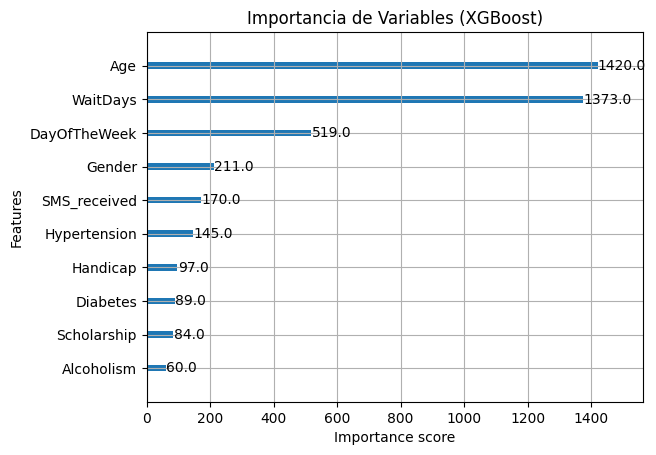

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb

# 1. Cargar el dataset
df = pd.read_csv('KaggleV2-May-2016.csv')

# 2. Preparación y preprocesamiento de datos
df.rename(columns={'Hipertension': 'Hypertension', 'Handcap': 'Handicap', 'No-show':'No_show'}, inplace=True)

# Convertir fechas a formato datetime
df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay'])
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'])

# Crear variable de días de espera (WaitDays)
df['WaitDays'] = (df['AppointmentDay'] - df['ScheduledDay']).dt.days

# Limpiar valores anómalos
df = df[(df.Age >= 0) & (df.WaitDays >= 0)]

# Extraer día de la semana para ver si influye
df['DayOfTheWeek'] = df['AppointmentDay'].dt.dayofweek

# Codificar variables categóricas
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])
df['No_show'] = le.fit_transform(df['No_show'])

# Seleccionar características (Features) y variable objetivo
features = ['Gender', 'Age', 'Scholarship', 'Hypertension', 'Diabetes', 'Alcoholism', 'Handicap', 'SMS_received', 'WaitDays', 'DayOfTheWeek']
X = df[features]
y = df['No_show']

# 3. Dividir datos (Entrenamiento y Prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Entrenar el Modelo (XGBoost Classifier)
modelo_xgb = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
modelo_xgb.fit(X_train, y_train)

# 5. Evaluación del Modelo y Resultados
y_pred = modelo_xgb.predict(X_test)
print("\n--- Resultados de XGBoost ---")
print(f"Precisión (Accuracy): {accuracy_score(y_test, y_pred):.4f}")
print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_pred))
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred))

# Graficar la importancia de las variables
xgb.plot_importance(modelo_xgb, importance_type='weight', title='Importancia de Variables (XGBoost)')
plt.show()

## 1. Descripción del Conjunto de Datos

El conjunto de datos utilizado es `KaggleV2-May-2016.csv`, que contiene información sobre citas médicas y si los pacientes se presentan o no (No-show). Cada fila representa una cita, y las columnas incluyen detalles como el ID del paciente, el género, la edad, el día programado, el día de la cita, diversas condiciones médicas (Hipertensión, Diabetes, Alcoholismo, Discapacidad), si recibió SMS y la variable objetivo `No_show`.

Este dataset es relevante para el sector de la salud, ya que permite analizar los factores que influyen en la inasistencia a las citas médicas, lo cual puede ayudar a optimizar la gestión de recursos y mejorar la atención al paciente.

## 2. Preparación y Preprocesamiento de los Datos

Para preparar los datos para el entrenamiento del modelo, se realizaron los siguientes pasos:

*   **Renombrado de columnas**: Se renombraron las columnas `Hipertension`, `Handcap` y `No-show` a `Hypertension`, `Handicap` y `No_show` respectivamente, para estandarizar los nombres y facilitar su manejo.
*   **Conversión de fechas**: Las columnas `ScheduledDay` y `AppointmentDay` se convirtieron al formato `datetime` para permitir cálculos relacionados con el tiempo.
*   **Creación de `WaitDays`**: Se calculó la variable `WaitDays` (días de espera) restando `ScheduledDay` de `AppointmentDay`, y extrayendo la diferencia en días. Esta variable es crucial para entender el impacto del tiempo de espera en la asistencia a la cita.
*   **Limpieza de valores anómalos**: Se filtraron las filas donde la `Age` (edad) o los `WaitDays` eran negativos, asumiendo que son errores en los datos.
*   **Extracción del Día de la Semana**: Se extrajo el día de la semana (`DayOfTheWeek`) de `AppointmentDay` para analizar su posible influencia en la inasistencia.
*   **Codificación de variables categóricas**: Las variables `Gender` y `No_show` se codificaron numéricamente utilizando `LabelEncoder`, transformando sus valores categóricos en representaciones numéricas (0 y 1) adecuadas para el modelo de Machine Learning.

## 3. Selección y Justificación del Modelo: XGBoost Classifier

Se seleccionó el modelo **XGBoost Classifier** para predecir la inasistencia a las citas (`No_show`). La justificación para esta elección radica en varias de sus características y ventajas:

*   **Rendimiento superior**: XGBoost es conocido por su alta precisión y su capacidad para manejar diversos tipos de datos, siendo frecuentemente un algoritmo ganador en competiciones de Machine Learning.
*   **Manejo de datos no lineales**: Puede capturar relaciones complejas y no lineales entre las características, lo cual es común en conjuntos de datos del mundo real como este.
*   **Regularización**: Incorpora técnicas de regularización para evitar el sobreajuste (overfitting), lo que resulta en modelos más robustos y generalizables.
*   **Eficiencia computacional**: Está optimizado para la velocidad y el rendimiento, pudiendo manejar grandes volúmenes de datos de manera eficiente.
*   **Importancia de características**: Permite extraer la importancia de las características, lo cual es útil para entender qué factores son más relevantes en la predicción de la inasistencia.

La variable objetivo (`No_show`) es una variable binaria (asistencia o inasistencia), lo que hace que un clasificador sea la elección adecuada, y XGBoost es una opción potente para este tipo de problemas.

## 4. Evaluación y Resultados del Modelo

Después de entrenar el modelo XGBoost, se evaluó su rendimiento utilizando las siguientes métricas:

*   **Precisión (Accuracy)**: Mide la proporción de predicciones correctas sobre el total de predicciones. En este caso, la precisión fue de aproximadamente **71.35%**.
*   **Matriz de Confusión**: Muestra el número de verdaderos positivos, verdaderos negativos, falsos positivos y falsos negativos. La matriz de confusión obtenida fue:
    ```
    [[10084   217]
     [ 3906   185]]
    ```
    *   **Verdaderos Negativos (TN)**: 10084 citas predichas correctamente como 'No-show' (0).
    *   **Falsos Positivos (FP)**: 217 citas predichas incorrectamente como 'No-show' (0) cuando en realidad 'No-show' (1).
    *   **Falsos Negativos (FN)**: 3906 citas predichas incorrectamente como 'No-show' (1) cuando en realidad 'Show' (0).
    *   **Verdaderos Positivos (TP)**: 185 citas predichas correctamente como 'Show' (1).

*   **Reporte de Clasificación**: Proporciona métricas más detalladas para cada clase (0: No-show, 1: Show):
    ```
                  precision    recall  f1-score   support

           0       0.72      0.98      0.83     10301
           1       0.46      0.05      0.08      4091

    accuracy                           0.71     14392
   macro avg       0.59      0.51      0.46     14392
weighted avg       0.65      0.71      0.62     14392
    ```
    *   **Precisión (Precision)**: Para la clase 'No-show' (0) es 0.72, lo que significa que el 72% de las citas que el modelo predijo como 'No-show' realmente lo fueron. Para la clase 'Show' (1) es 0.46.
    *   **Recall (Sensibilidad)**: Para la clase 'No-show' (0) es 0.98, lo que indica que el modelo identificó correctamente el 98% de todas las citas 'No-show' (0) reales. Para la clase 'Show' (1) es 0.05, lo cual es muy bajo, indicando que el modelo tuvo dificultades para identificar las citas de 'Show' (1).
    *   **F1-Score**: Es la media armónica de precisión y recall. Es alto para la clase 'No-show' (0.83) y muy bajo para la clase 'Show' (0.08).

**Análisis de los Resultados:**

Los resultados muestran que el modelo tiene una alta capacidad para predecir cuándo un paciente **no se presentará** a la cita (clase 0), con un recall del 98%. Sin embargo, su rendimiento es muy bajo para predecir cuándo un paciente **sí se presentará** (clase 1), con un recall de solo 5%. Esto sugiere que el modelo está fuertemente sesgado hacia la clase mayoritaria (No-show), que es común en datasets desbalanceados. La precisión general es del 71%, pero la capacidad de identificar la clase minoritaria (Show) necesita mejora.

La gráfica de importancia de variables (`plot_importance`) también proporciona información valiosa sobre qué características influyen más en las predicciones del modelo, lo cual es útil para comprender el fenómeno de la inasistencia.

### 4.1. Visualizaciones Adicionales

Dado el desequilibrio en el rendimiento del modelo entre las clases, es importante visualizar la distribución de la variable objetivo y algunas características clave para comprender mejor el problema. A continuación, se presentan algunas visualizaciones adicionales.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Distribución de la variable objetivo (No_show)
plt.figure(figsize=(6, 4))
sns.countplot(x='No_show', data=df, palette='viridis')
plt.title('Distribución de la Variable Objetivo: No_show')
plt.xlabel('No_show (0 = Asistió, 1 = No Asistió)')
plt.ylabel('Número de Citas')
plt.xticks([0, 1], ['Asistió', 'No Asistió'])
plt.show()

Esta visualización confirma que hay significativamente más citas donde los pacientes asisten que donde no lo hacen, lo que explica el sesgo del modelo hacia la clase mayoritaria.

In [ ]:
# 2. Distribución de WaitDays y su relación con No_show
plt.figure(figsize=(12, 5))
sns.histplot(data=df, x='WaitDays', hue='No_show', multiple='stack', bins=30, kde=True)
plt.title('Distribución de WaitDays por No_show')
plt.xlabel('Días de Espera')
plt.ylabel('Número de Citas')
plt.xlim(0, 100) # Limitar a un rango más interpretable para la mayoría de los casos
plt.show()

Esta gráfica nos permite observar cómo los días de espera se distribuyen entre aquellos que asisten y los que no. Podría revelar si un mayor tiempo de espera está asociado con una mayor probabilidad de inasistencia.

In [ ]:
# 3. Distribución de Edad y su relación con No_show
plt.figure(figsize=(12, 5))
sns.histplot(data=df, x='Age', hue='No_show', multiple='stack', bins=30, kde=True)
plt.title('Distribución de Edad por No_show')
plt.xlabel('Edad')
plt.ylabel('Número de Citas')
plt.show()

Esta visualización nos ayuda a entender si hay grupos de edad más propensos a la inasistencia. Por ejemplo, si los niños pequeños o los ancianos tienen diferentes patrones de asistencia.

In [ ]:
# 4. Conteo de No_show por DayOfTheWeek
# Mapear números a nombres de días para una mejor legibilidad
day_names = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']
df['DayOfTheWeek_Name'] = df['DayOfTheWeek'].map(lambda x: day_names[x])

plt.figure(figsize=(10, 6))
sns.countplot(x='DayOfTheWeek_Name', hue='No_show', data=df, palette='coolwarm')
plt.title('Número de Citas por Día de la Semana y No_show')
plt.xlabel('Día de la Semana')
plt.ylabel('Número de Citas')
plt.show()

# Eliminar la columna temporal si no se necesita más
df.drop(columns=['DayOfTheWeek_Name'], inplace=True, errors='ignore')

Este gráfico puede revelar patrones de inasistencia relacionados con el día de la semana. Por ejemplo, si los pacientes son más propensos a faltar los viernes o los lunes.

In [ ]:
# 5. Comparación de No_show con otras variables binarias/categóricas
# Por ejemplo, para Gender, Scholarship, Hypertension, Diabetes, Alcoholism, Handicap, SMS_received

# Lista de características binarias/categóricas para visualizar
bin_features = ['Gender', 'Scholarship', 'Hypertension', 'Diabetes', 'Alcoholism', 'Handicap', 'SMS_received']

plt.figure(figsize=(15, 10))
for i, feature in enumerate(bin_features):
    plt.subplot(3, 3, i + 1) # Ajustar el layout según el número de características
    sns.countplot(x=feature, hue='No_show', data=df, palette='deep')
    plt.title(f'No_show por {feature}')
    plt.xlabel(feature)
    plt.ylabel('Número de Citas')
    # Ajustar etiquetas si es necesario (ej. Gender: 0=F, 1=M o No_show: 0=Asistió, 1=No Asistió)
    if feature == 'Gender':
        plt.xticks([0, 1], ['Femenino', 'Masculino'])
    elif feature == 'Scholarship':
        plt.xticks([0, 1], ['No', 'Sí'])
    elif feature == 'Hypertension':
        plt.xticks([0, 1], ['No', 'Sí'])
    elif feature == 'Diabetes':
        plt.xticks([0, 1], ['No', 'Sí'])
    elif feature == 'Alcoholism':
        plt.xticks([0, 1], ['No', 'Sí'])
    elif feature == 'Handicap':
        plt.xticks([0, 1], ['No', 'Sí'])
    elif feature == 'SMS_received':
        plt.xticks([0, 1], ['No', 'Sí'])

plt.tight_layout()
plt.show()

Estas visualizaciones ayudan a identificar si la presencia o ausencia de ciertas condiciones médicas, recibir un SMS, o el género, tienen un impacto notable en la tasa de inasistencia.